In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import muon as mu
import anndata as ad
from scipy.io import mmread
import sys
import os
from pathlib import Path
import seaborn as sns

%load_ext autoreload
%autoreload 2
%matplotlib inline

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata

In [2]:
# --- Configuration ---

# Add project root to sys.path (important for notebooks to find 'src')
# This is a common pattern in notebooks to ensure imports work
# Find project root by searching for the directory containing 'src'
project_root = None
current_dir = Path.cwd()
# Check current dir and its parents for a 'src' subdirectory
for parent in [current_dir] + list(current_dir.parents):
    if (parent / 'src').is_dir():
        project_root = parent
        break

if project_root and str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print(f"Added {project_root} to sys.path")
elif not project_root:
    print("Warning: Could not automatically find project root. Imports from src.* might fail.")
    print("Please ensure you run this notebook from the project root or add it to sys.path manually.")


try:
    # Import config module and genome loading function from the src package
    from src import config
    from src.genomic_annotation import load_gencode_gtf_genes
    
    print("Successfully imported config and load_gencode_gtf_genes from src")
except ImportError as e:
    print(f"Error importing config: {e}")
    print("Please check your project structure and ensure src/__init__.py exists.")

# Define the path to the specific mouse brain data subdirectory
# Use the DATA_DIR from config and join with the subdirectory name
# Since config.DATA_DIR is already a Path object, use the / operator
MOUSE_BRAIN_DATA_DIR = config.DATA_DIR / "mouse_brain_data"
H5AD_DIR = config.H5AD_DIR

# Now define your file paths using the MOUSE_BRAIN_DATA_DIR variable
RNA_COUNTS_FILE = MOUSE_BRAIN_DATA_DIR / "GSM4156610_brain.rna.counts.txt.gz"
ATAC_COUNTS_FILE = MOUSE_BRAIN_DATA_DIR / "GSM4156599_brain.counts.txt.gz"
ATAC_PEAKS_FILE = MOUSE_BRAIN_DATA_DIR / "GSM4156599_brain.peaks.bed.gz"
CELLTYPE_FILE = MOUSE_BRAIN_DATA_DIR / "GSM4156599_brain_celltype.txt.gz"
ATAC_BARCODES_FILE = MOUSE_BRAIN_DATA_DIR / "GSM4156599_brain.barcodes.txt.gz"
ATAC_FRAGMENTS_FILE = MOUSE_BRAIN_DATA_DIR / "GSM4156599_brain.atac.fragments.sorted.bed.gz"
ATAC_UNSORTED_FRAGMENTS_FILE = MOUSE_BRAIN_DATA_DIR / "GSM4156599_brain.atac.fragments.bed.gz"

Added /nfs/home/students/l.reich/tangram to sys.path
Successfully imported config and load_gencode_gtf_genes from src


## scRNA

In [3]:
# Load the cell type/pairing file
# This file links ATAC and RNA barcodes for the paired cells (3293 cells)

df_celltype = pd.read_csv(CELLTYPE_FILE, sep='\t')

In [4]:
df_celltype = df_celltype.set_index('rna.bc')

In [5]:
# Get the list of paired RNA barcodes to use as common cell IDs

common_cell_ids = df_celltype.index.tolist()

In [6]:
# Load RNA counts matrix (Genes x Cells)

df_rna_counts = pd.read_csv(RNA_COUNTS_FILE, sep='\t', index_col=0)

In [7]:
# Clean the column names (cell barcodes) in the RNA counts DataFrame
# They use commas (,) but the celltype file uses periods (.)
# Replace commas with periods to match the common_cell_ids format

df_rna_counts.columns = df_rna_counts.columns.str.replace(',', '.', regex=False)

In [8]:
# Subset the RNA counts DataFrame to keep only the columns (cells) that are in our paired set
# This aligns the RNA data to the 3293 paired cells
# .reindex(columns=...) will select the columns and also handle cases where a barcode might be missing (inserts NaNs)
# We use .dropna(axis=1) to remove any columns that were entirely NaN if reindexing failed
df_rna_subset = df_rna_counts.reindex(columns=common_cell_ids).dropna(axis=1)

In [9]:
# Verify that the columns now exactly match the common cell IDs
if list(df_rna_subset.columns) != common_cell_ids:
     print("Error: Subsetting RNA counts failed to exactly match common cell IDs!")
     # Handle error - critical for alignment
else:
     print("RNA counts columns successfully subsetted and aligned to common cell IDs.")

RNA counts columns successfully subsetted and aligned to common cell IDs.


In [10]:
# Transpose the DataFrame to be Cells x Genes for AnnData
df_rna_transposed = df_rna_subset.T.copy() # Use .T for transpose and .copy()

In [11]:
# Create the AnnData object for RNA
# X: The transposed counts matrix (Paired_Cells x Genes)
# obs: Observation metadata (cells). Index should be the common cell IDs.
# var: Variable metadata (genes). Index should be the gene IDs.
adata_rna = ad.AnnData(
    X=df_rna_transposed,
    obs=pd.DataFrame(index=df_rna_transposed.index), # Use transposed index (common cell IDs) for obs names
    var=pd.DataFrame(index=df_rna_transposed.columns) # Use transposed columns (gene IDs) for var names
)

In [12]:
# Add cell type annotations to adata_rna.obs
# The index of adata_rna.obs is common_cell_ids (rna.bc)
# The index of df_celltype is also rna.bc
# Merge df_celltype (keeping only the 'celltype' column) into adata_rna.obs
adata_rna.obs = adata_rna.obs.merge(df_celltype[['celltype']], left_index=True, right_index=True, how='left')

### scRNA QC

Check for mitochondrial genes

In [13]:
adata_rna.var_names.str.startswith("Mt-").sum()

0

In [14]:
sc.pp.calculate_qc_metrics(
    adata_rna, inplace=True, log1p=True
)

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


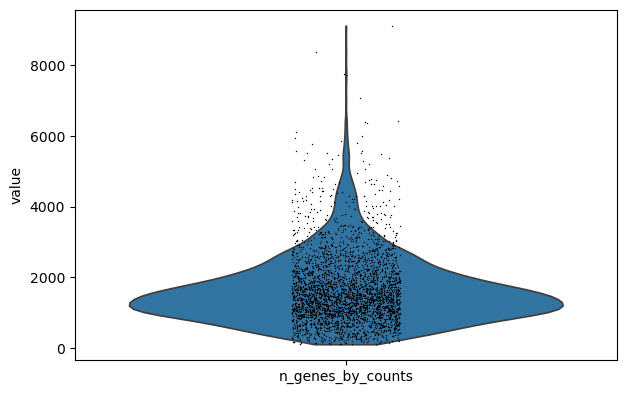

In [15]:
sc.pl.violin(
    adata_rna,
    ["n_genes_by_counts"]
)

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


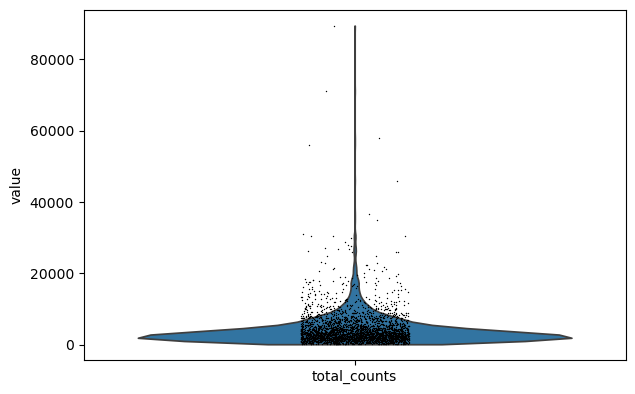

In [16]:
sc.pl.violin(
    adata_rna,
    ["total_counts"]
)

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_utils.py:715: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


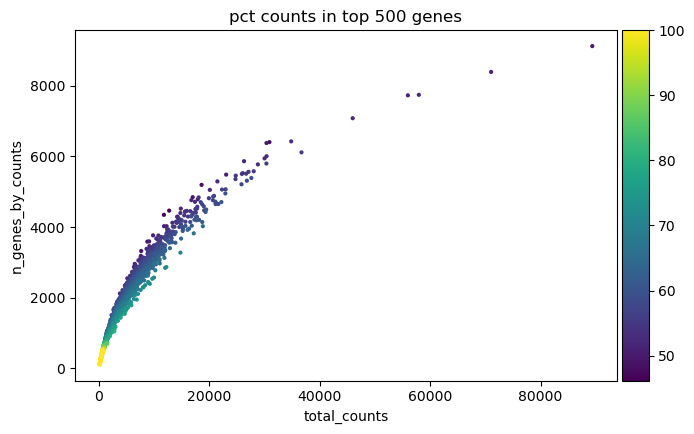

In [17]:
sc.pl.scatter(adata_rna, "total_counts", "n_genes_by_counts", color="pct_counts_in_top_500_genes")

In [18]:
sc.pp.filter_cells(adata_rna, min_genes=100)

In [19]:
sc.pp.filter_genes(adata_rna, min_cells=2)

In [20]:
#sc.pp.scrublet(adata_rna, copy=True)

### Normalization

In [21]:
# Saving count data
adata_rna.layers["counts"] = adata_rna.X.copy()

In [22]:
# Normalizing to median total counts
sc.pp.normalize_total(adata_rna)
# Logarithmize the data
sc.pp.log1p(adata_rna)

### Feature Selection

In [23]:
sc.pp.highly_variable_genes(adata_rna, n_top_genes=2000)

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:220: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']


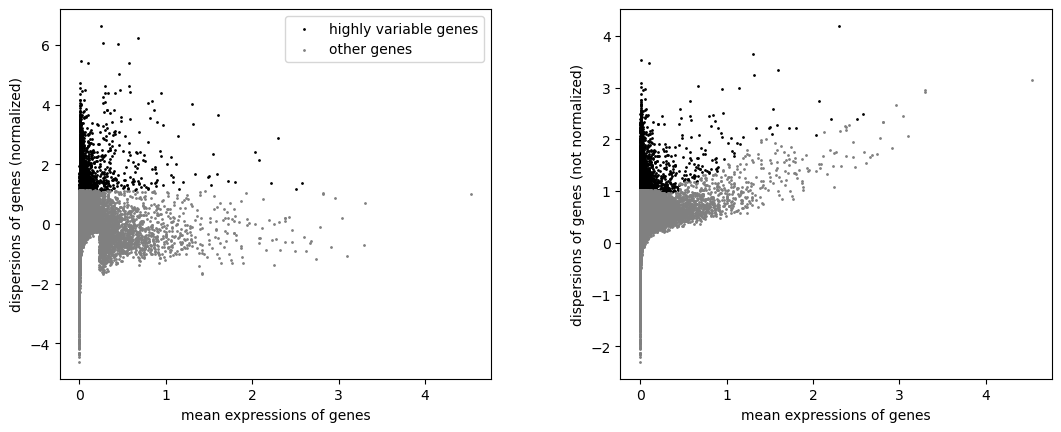

In [24]:
sc.pl.highly_variable_genes(adata_rna)

### Dimensionality Reduction

In [25]:
sc.tl.pca(adata_rna)

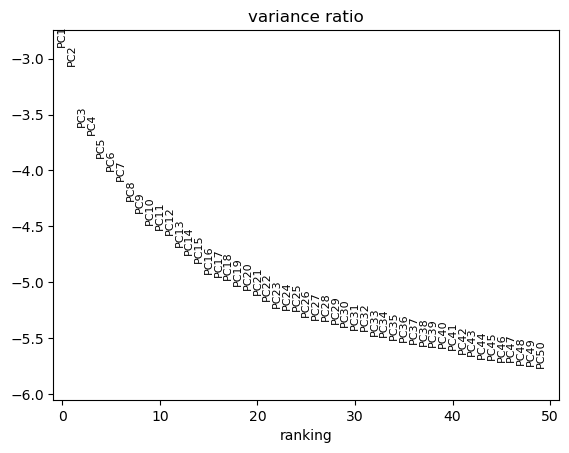

In [26]:
sc.pl.pca_variance_ratio(adata_rna, n_pcs=50, log=True)

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


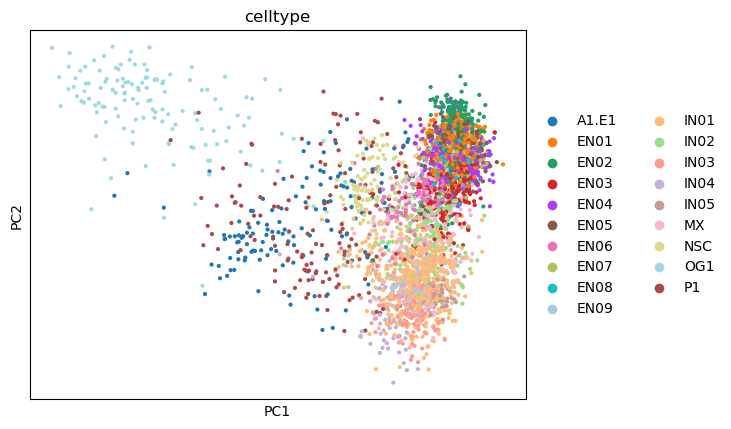

In [27]:
sc.pl.pca(
    adata_rna, color="celltype"
)

In [28]:
sc.pp.neighbors(adata_rna)

In [29]:
sc.tl.umap(adata_rna)

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


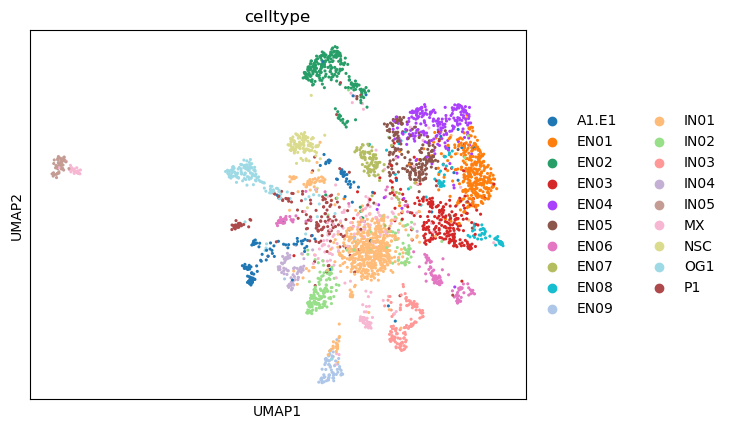

In [30]:
sc.pl.umap(
    adata_rna,
    color="celltype",
    # Setting a smaller point size to get prevent overlap
    size=20,
)

In [31]:
sc.tl.leiden(adata_rna)

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


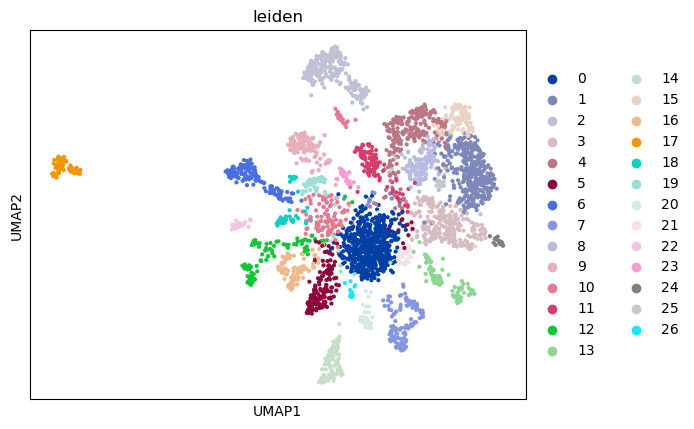

In [32]:
sc.pl.umap(adata_rna, color=["leiden"])

In [33]:
# write adata_sc to disk

ad_rna_path = H5AD_DIR / "c_sc_ad.h5ad"
#adata_rna.write_h5ad(ad_rna_path)

## scATAC

In [13]:
cell_meta = pd.read_csv(CELLTYPE_FILE, sep="\t")

# Load ATAC data
atac = sc.read_mtx(ATAC_COUNTS_FILE).T
barcodes = pd.read_csv(ATAC_BARCODES_FILE, header=None)
atac.obs["barcode"] = barcodes[0].values

# Load peaks
peaks = pd.read_csv(ATAC_PEAKS_FILE, sep="\t", header=None, names=["chrom", "start", "end"])
peaks["peak_id"] = peaks["chrom"] + ":" + peaks["start"].astype(str) + "-" + peaks["end"].astype(str)
peaks.set_index("peak_id", inplace=True)
atac.var = peaks

# Since barcodes.txt.gz contains RNA barcodes, we need to map them to ATAC barcodes
# Create a mapping dictionary from RNA to ATAC
rna_to_atac = dict(zip(cell_meta["rna.bc"], cell_meta["atac.bc"]))

# Add ATAC barcode column based on RNA barcodes
atac.obs["atac_barcode"] = [rna_to_atac.get(bc, "unknown") for bc in atac.obs["barcode"]]

# Format ATAC barcodes for fragments file
import re
formatted_barcodes = []
for bc in atac.obs["atac_barcode"]:
    components = re.findall(r'(R\d+\.\d+|P\d+\.\d+)', bc)
    formatted_bc = ','.join(components)
    formatted_barcodes.append(formatted_bc)

# Add formatted barcodes
atac.obs["formatted_barcode"] = formatted_barcodes

# Set formatted barcodes as observation names
atac.obs_names = atac.obs["formatted_barcode"].values

# Add cell type information directly
atac.obs["celltype"] = atac.obs["barcode"].map(dict(zip(cell_meta["rna.bc"], cell_meta["celltype"])))

In [14]:
mu.atac.tl.locate_fragments(atac, str(ATAC_FRAGMENTS_FILE))

In [38]:
'''
atac_path = H5AD_DIR / "c_atac_ad.h5ad"
atac.write_h5ad(atac_path)
'''

'\natac_path = H5AD_DIR / "c_atac_ad.h5ad"\natac.write_h5ad(atac_path)\n'

### scATAC QC

In [39]:
# Calculate general qc metrics using scanpy
sc.pp.calculate_qc_metrics(atac, percent_top=None, log1p=False, inplace=True)

# Rename columns
atac.obs.rename(
    columns={
        "n_genes_by_counts": "n_features_per_cell",
        "total_counts": "total_fragment_counts",
    },
    inplace=True,
)

# log-transform total counts and add as column
atac.obs["log_total_fragment_counts"] = np.log10(atac.obs["total_fragment_counts"])

In [40]:
# Calculate the nucleosome signal across cells
# set n=10e3*atac.n_obs for rough estimate but faster run time
mu.atac.tl.nucleosome_signal(atac, n=20000000)

Reading Fragments: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20000000/20000000 [01:28<00:00, 226133.20it/s]


<Axes: xlabel='nucleosome_signal', ylabel='Count'>

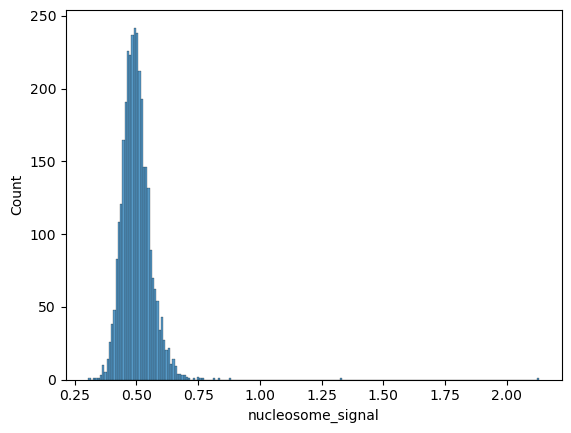

In [41]:
sns.histplot(atac.obs, x="nucleosome_signal")

In [42]:
# Add group labels for above and below the nucleosome signal threshold
nuc_signal_threshold = 2
atac.obs["nuc_signal_filter"] = [
    "NS_FAIL" if ns > nuc_signal_threshold else "NS_PASS"
    for ns in atac.obs["nucleosome_signal"]
]

# Print number cells not passing nucleosome signal threshold
atac.obs["nuc_signal_filter"].value_counts()

nuc_signal_filter
NS_PASS    3292
NS_FAIL       1
Name: count, dtype: int64

<Axes: xlabel='total_fragment_counts', ylabel='n_features_per_cell'>

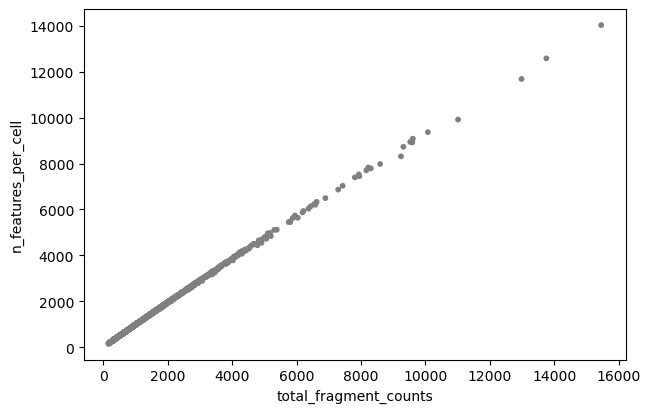

In [43]:
sc.pl.scatter(
    atac,
    x="total_fragment_counts",
    y="n_features_per_cell",
    size=70,
    show=False,  # so that funstion output axis object where threshold line can be drawn.
)

In [44]:
pp = atac.copy()

In [45]:
print(f"Total number of cells: {pp.n_obs}")
mu.pp.filter_obs(
    pp,
    "total_fragment_counts",
    lambda x:  (x >= 165) &(x <= 12000),
)
print(f"Number of cells after filtering on total_fragment_counts: {pp.n_obs}")

Total number of cells: 3293
Number of cells after filtering on total_fragment_counts: 3288


In [46]:
mu.pp.filter_var(pp, "n_cells_by_counts", lambda x: x >= 2)

In [47]:
len(pp.var)/len(atac.var)

0.8907581283101386

In [48]:
atac_path = H5AD_DIR / "c_atac_ad.h5ad"
pp.write_h5ad(atac_path)

In [49]:
#optional: assign atac back to pp for downstream processing
atac = pp

In [50]:
# Keep only cells in adata_rna that are also present in atac
adata_rna = adata_rna[adata_rna.obs_names.isin(atac.obs["barcode"])].copy()

In [51]:
# write (new filtered) adata_sc to disk

adata_rna.write_h5ad(ad_rna_path)

## Aggregate fragments to genes

In [52]:
# Define the GTF URL
gtf_url = "https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_mouse/release_M10/gencode.vM10.annotation.gtf.gz"

# Load and process the genes, excluding chrY
try:
    gene_coords_gencode = load_gencode_gtf_genes(gtf_url, feature_type='gene', exclude_chroms=['chrY'])
except Exception as e:
    print(f"Failed to load or process GTF: {e}")

Successfully processed GTF from https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_mouse/release_M10/gencode.vM10.annotation.gtf.gz.
Number of 'gene' features found: 46870
Excluded chromosomes: ['chrY']


In [53]:
gene_coords_gencode = gene_coords_gencode[~gene_coords_gencode["chrom"].str.contains("chrY")]

In [54]:
# intersection with RNA data
common_genes_gencode = adata_rna.var_names.intersection(gene_coords_gencode.index)
print(f"\nNumber of common genes with RNA data (GENCODE M10): {len(common_genes_gencode)}")


Number of common genes with RNA data (GENCODE M10): 18696


In [55]:
adata_rna_annotated = adata_rna[:, list(common_genes_gencode)].copy()

In [56]:
# Group by gene_name and take the lowest start position
'''
gene_coords_gencode_filtered = gene_coords_gencode.loc[common_genes_gencode].groupby(level=0).agg({
    'chrom': 'first',  # Keep the chromosome
    'start': 'min',  # Use the smallest start site (most upstream TSS)
    'end': 'max',  # Use the largest end site (covers all isoforms)
    'Strand': 'first',  # Keep strand information
    'gene_ids': 'first'
})
'''

"\ngene_coords_gencode_filtered = gene_coords_gencode.loc[common_genes_gencode].groupby(level=0).agg({\n    'chrom': 'first',  # Keep the chromosome\n    'start': 'min',  # Use the smallest start site (most upstream TSS)\n    'end': 'max',  # Use the largest end site (covers all isoforms)\n    'Strand': 'first',  # Keep strand information\n    'gene_ids': 'first'\n})\n"

In [57]:
gene_coords_gencode_reset = gene_coords_gencode.reset_index()

gene_coords_gencode_filtered = (
    gene_coords_gencode_reset
    .loc[gene_coords_gencode_reset['gene_name'].isin(common_genes_gencode)]
    .groupby(['gene_name', 'chrom'])
    .agg({
        'start': 'min',
        'end': 'max',
        'Strand': 'first',
        'gene_ids': 'first'
    })
    .reset_index()
)

gene_coords_gencode_filtered = gene_coords_gencode_filtered[
    ~((gene_coords_gencode_filtered['gene_name'] == 'Fth1') &
      (gene_coords_gencode_filtered['chrom'] == 'chr8'))
]

gene_coords_gencode_filtered = gene_coords_gencode_filtered.set_index('gene_name')

In [58]:
mdata = mu.MuData({'rna': adata_rna_annotated, 'atac': atac})

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [59]:
mu.atac.tl.initialise_default_files(mdata, path=MOUSE_BRAIN_DATA_DIR)

In [60]:
'''
adata_atac_genes = mu.atac.tl.count_fragments_features(
    mdata,
    features=gene_coords_gencode_filtered,
    stranded=True,
    count_reads=False
)
'''

'\nadata_atac_genes = mu.atac.tl.count_fragments_features(\n    mdata,\n    features=gene_coords_gencode_filtered,\n    stranded=True,\n    count_reads=False\n)\n'

In [61]:
sc.pp.filter_genes(adata_atac_genes, min_cells=2)

NameError: name 'adata_atac_genes' is not defined

### scATAC/genes normalization

In [ ]:
# Saving count data
#adata_atac_genes.layers["counts"] = adata_atac_genes.X.copy()

In [ ]:
'''
# Normalizing to median total counts
sc.pp.normalize_total(adata_atac_genes)
# Logarithmize the data
sc.pp.log1p(adata_atac_genes)
'''

In [ ]:
#adata_atac_genes.write_h5ad(str(H5AD_DIR / "c_atac_genes_ad.h5ad"))

In [ ]:
adata_atac_genes = sc.read_h5ad(config.get_h5ad_path("c_atac_genes_ad.h5ad"))

In [ ]:
# Ensure gene_coords_gencode_filtered has the 'interval' column if it doesn't already
if 'interval' not in gene_coords_gencode_filtered.columns:
    gene_coords_gencode_filtered['interval'] = \
        gene_coords_gencode_filtered['chrom'].astype(str) + ':' + \
        gene_coords_gencode_filtered['start'].astype(str) + '-' + \
        gene_coords_gencode_filtered['end'].astype(str)

# Ensure the index names match before merging
mdata['rna'].var.index.name = 'gene_name'
gene_coords_gencode_filtered.index.name = 'gene_name'


# Select only the necessary columns from gene_coords_gencode_filtered for the merge
gene_info_for_merge = gene_coords_gencode_filtered[['chrom', 'start', 'end', 'Strand', 'interval', 'gene_ids']]

# Merge the gene annotation information into the .var DataFrame of the RNA modality
mdata['rna'].var = mdata['rna'].var.merge(
    gene_info_for_merge,
    left_index=True,
    right_index=True,
    how='left' # Use a left merge to keep all genes in mdata['rna'].var
)

In [ ]:
# Plot nucleosome signal distribution across cells
mu.atac.tl.nucleosome_signal(atac, n=1e6)
mu.pl.histogram(atac, "nucleosome_signal")